# La sfida tra i modelli

*Il team WristMind ha una domanda scomoda: "Perché usare una rete neurale? I modelli più vecchi non fanno già abbastanza?" È una domanda giusta. Un buon ingegnere non usa lo strumento più complicato solo perché esiste, usa quello più adatto al problema.*

**In questo notebook mettiamo alla prova i nostri modelli.** Li faremo gareggiare su due fronti: classificazione (le sei attività) e regressione (stimare l'intensità di un'attività). Misureremo accuratezza, tempo di addestramento e tempi di risposta. Poi scopriremo il nemico numero uno di tutti i modelli: l'overfitting. E impareremo la prima difesa efficace: il Dropout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error

os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf

from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

print("Carico il dataset HAR...")
har = fetch_openml(data_id=1478, as_frame=True, parser='auto')
X = har.data.astype(np.float32)
y = har.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

y_train_0 = y_train - 1
y_test_0  = y_test  - 1

print(f"Training: {X_train_sc.shape[0]} campioni, Test: {X_test_sc.shape[0]} campioni")

Carico il dataset HAR...
Training: 7724 campioni, Test: 2575 campioni


## La rete neurale per la regressione

Finora abbiamo usato la rete per classificazione: uscita categorica (quale classe?). Ma le reti neurali funzionano bene anche per la **regressione**: prevedere un valore continuo.

Creiamo un target sintetico ma realistico: l'**intensità metabolica** dell'attività, misurata in unità MET (Metabolic Equivalent of Task). Assegniamo valori base a ciascuna attività e aggiungiamo un po' di rumore per simulare variabilità inter-individuale.

Valori approssimativi MET per attività:
- Sdraiato: 1.0 MET
- Seduto: 1.5 MET
- In piedi: 2.0 MET
- Scendere scale: 5.0 MET
- Camminare: 4.0 MET
- Salire scale: 6.0 MET

In [2]:
# Creiamo il target di regressione: intensita' metabolica (MET)
# Mappa da classe (1..6) a valore continuo
rng = np.random.default_rng(seed=42)
mappa_met = {1: 4.0, 2: 6.0, 3: 5.0, 4: 1.5, 5: 2.0, 6: 1.0}

y_train_reg = np.array([mappa_met[c] for c in y_train.values], dtype=np.float32)
y_test_reg  = np.array([mappa_met[c] for c in y_test.values],  dtype=np.float32)

# Aggiungiamo rumore gaussiano per simulare variabilita' reale
y_train_reg += rng.normal(0, 0.5, size=y_train_reg.shape).astype(np.float32)
y_test_reg  += rng.normal(0, 0.5, size=y_test_reg.shape).astype(np.float32)
y_train_reg = np.clip(y_train_reg, 0.5, 8.0)
y_test_reg  = np.clip(y_test_reg,  0.5, 8.0)

print(f"Target regressione - min: {y_train_reg.min():.2f}, max: {y_train_reg.max():.2f}")
print(f"Media per classe:")
for c, nome in {1:'Camminare',2:'Salire',3:'Scendere',4:'Seduto',5:'In piedi',6:'Sdraiato'}.items():
    idx = (y_train.values == c)
    print(f"  {nome:15s}: MET medio = {y_train_reg[idx].mean():.2f}")

Target regressione - min: 0.50, max: 7.46
Media per classe:
  Camminare      : MET medio = 4.00
  Salire         : MET medio = 6.00
  Scendere       : MET medio = 4.99
  Seduto         : MET medio = 1.49
  In piedi       : MET medio = 1.98
  Sdraiato       : MET medio = 1.05


In [3]:
# Rete neurale per regressione
# L'unica differenza rispetto alla classificazione:
# - strato di uscita: 1 neurone SENZA funzione di attivazione (output lineare)
# - funzione costo: 'mse' (mean squared error) invece di cross-entropy

modello_reg = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)   # nessuna attivazione = uscita lineare
], name="rete_regressione")

modello_reg.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error: penalizza di piu' errori grandi
    metrics=['mae']  # Mean Absolute Error: piu' facile da interpretare di MSE
)

storia_reg = modello_reg.fit(
    X_train_sc, y_train_reg,
    epochs=40, batch_size=64, validation_split=0.2, verbose=0
)

y_pred_reg = modello_reg.predict(X_test_sc, verbose=0).flatten()
mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"MAE sul test set: {mae:.3f} MET")
print(f"(Errore medio assoluto nella stima dell'intensita' metabolica)")

MAE sul test set: 0.518 MET
(Errore medio assoluto nella stima dell'intensita' metabolica)


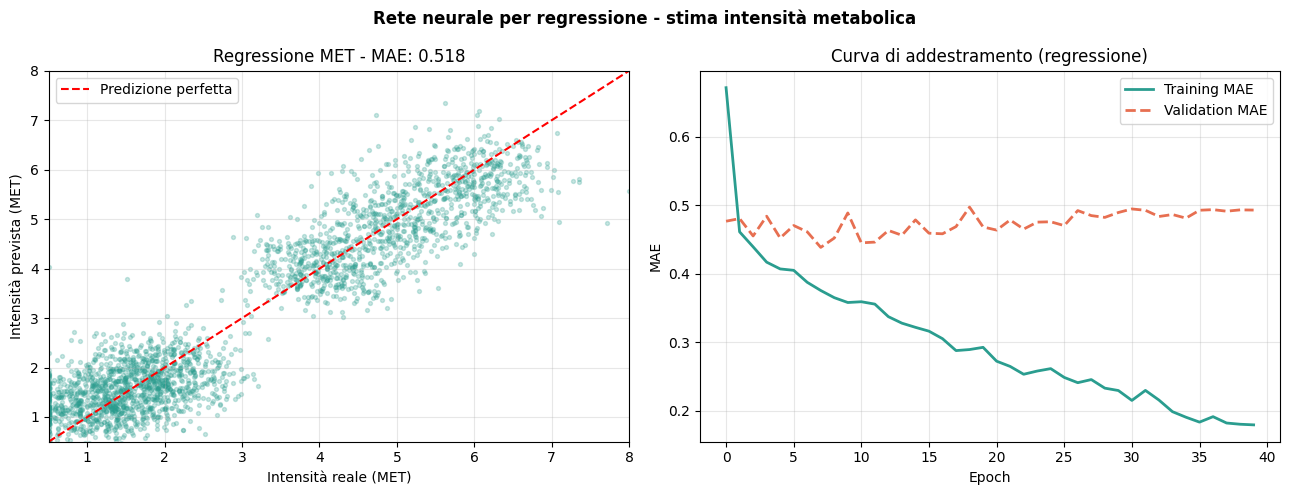

In [4]:
# Scatter plot: valori reali vs. predetti
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

scatter = ax1.scatter(y_test_reg, y_pred_reg,
                      alpha=0.25, s=8, color='#2a9d8f')
lim = [0.5, 8.0]
ax1.plot(lim, lim, 'r--', linewidth=1.5, label='Predizione perfetta')
ax1.set_xlabel("Intensità reale (MET)")
ax1.set_ylabel("Intensità prevista (MET)")
ax1.set_title(f'Regressione MET - MAE: {mae:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(lim)
ax1.set_ylim(lim)

# Curva di addestramento
ax2.plot(storia_reg.history['mae'],
         label='Training MAE', color='#2a9d8f', linewidth=2)
ax2.plot(storia_reg.history['val_mae'],
         label='Validation MAE', color='#e76f51', linewidth=2, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Curva di addestramento (regressione)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Rete neurale per regressione - stima intensità metabolica',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## La sfida: reti neurali vs. modelli classici

Ora passiamo alla classificazione delle sei attività. Mettiamo a confronto tre modelli che conoscete:

1. **k-NN** (k-Nearest Neighbors): classifica in base ai $k$ vicini più simili
2. **Regressione Logistica**: il cugino multiclasse della regressione lineare
3. **MLP** (la nostra rete multi-strato)

Per ogni modello misuriamo:
- **Accuratezza sul test** (più alta è meglio)
- **Tempo di addestramento** (quanto ci vuole per imparare)
- **Tempo di inferenza** (quanto veloce è a fare previsioni)

In [5]:
# Dizionario dei modelli da confrontare
# Usiamo parametri ragionevoli per ogni modello
modelli = {
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Logistica":  LogisticRegression(max_iter=200, random_state=42, n_jobs=-1),
}

risultati_confronto = []

# --- Modelli sklearn ---
for nome, modello in modelli.items():
    t0 = time.time()
    modello.fit(X_train_sc, y_train_0)
    t_train = time.time() - t0

    t0 = time.time()
    y_pred = modello.predict(X_test_sc)
    t_inf = (time.time() - t0) * 1000  # millisecondi

    acc = accuracy_score(y_test_0, y_pred)
    risultati_confronto.append({
        "Modello": nome,
        "Accuratezza": acc,
        "T. training (s)": round(t_train, 2),
        "T. inferenza (ms)": round(t_inf, 1)
    })
    print(f"{nome:20s}: acc={acc:.1%}, train={t_train:.1f}s, inf={t_inf:.1f}ms")

# --- MLP Keras ---
mlp_comp = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])
mlp_comp.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

t0 = time.time()
mlp_comp.fit(X_train_sc, y_train_0, epochs=50,
             batch_size=64, validation_split=0.2, verbose=0)
t_train_mlp = time.time() - t0

t0 = time.time()
y_pred_mlp = np.argmax(mlp_comp.predict(X_test_sc, verbose=0), axis=1)
t_inf_mlp = (time.time() - t0) * 1000

acc_mlp = accuracy_score(y_test_0, y_pred_mlp)
risultati_confronto.append({
    "Modello": "MLP (128+64)",
    "Accuratezza": acc_mlp,
    "T. training (s)": round(t_train_mlp, 2),
    "T. inferenza (ms)": round(t_inf_mlp, 1)
})
print(f"{'MLP (128+64)':20s}: acc={acc_mlp:.1%}, train={t_train_mlp:.1f}s, inf={t_inf_mlp:.1f}ms")

k-NN (k=5)          : acc=96.3%, train=0.0s, inf=642.8ms
Logistica           : acc=98.1%, train=4.4s, inf=17.6ms
MLP (128+64)        : acc=98.4%, train=19.0s, inf=241.4ms


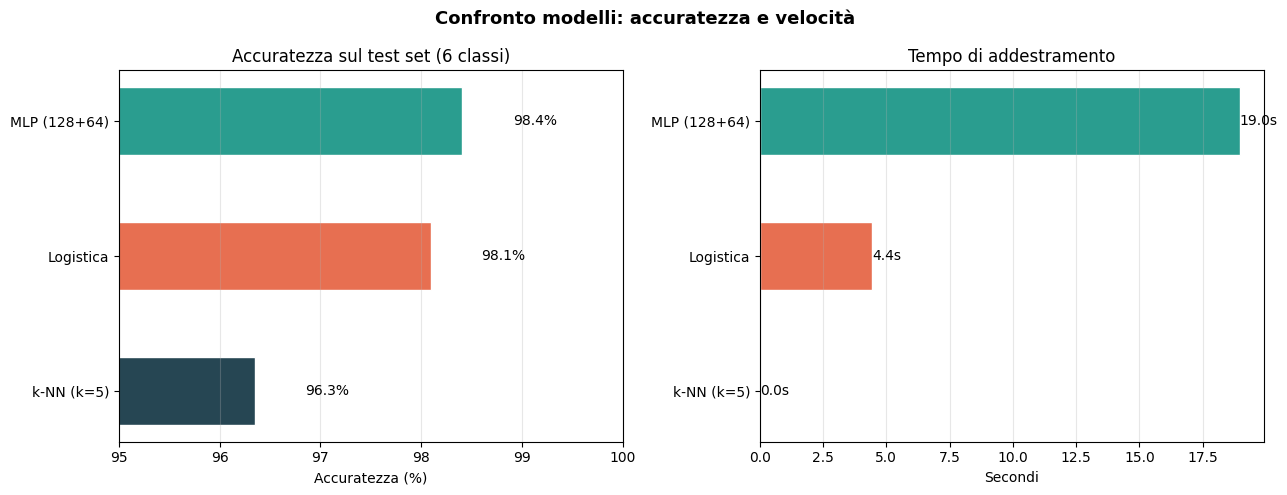


Tabella completa:
     Modello  Accuratezza  T. training (s)  T. inferenza (ms)
  k-NN (k=5)     0.963495             0.01              642.8
   Logistica     0.980971             4.42               17.6
MLP (128+64)     0.984078            18.96              241.4


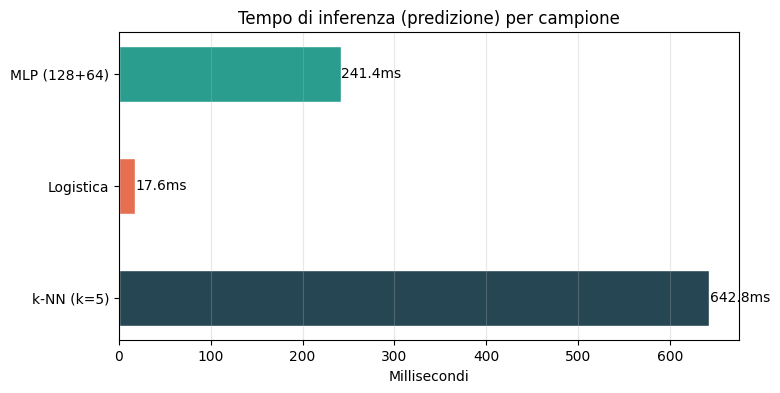

In [6]:
# Grafico di confronto
df_comp = pd.DataFrame(risultati_confronto)
nomi = df_comp["Modello"]
accs = df_comp["Accuratezza"] * 100
colori = ['#264653', '#e76f51', '#2a9d8f']

fig, assi = plt.subplots(1, 2, figsize=(13, 5))

# Accuratezza
bars = assi[0].barh(nomi, accs, color=colori, height=0.5, edgecolor='white')
assi[0].set_xlabel('Accuratezza (%)')
assi[0].set_title('Accuratezza sul test set (6 classi)')
assi[0].set_xlim([95, 100])
assi[0].grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, accs):
    assi[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)

# Tempo di training
t_trains = df_comp["T. training (s)"]
bars2 = assi[1].barh(nomi, t_trains, color=colori, height=0.5, edgecolor='white')
assi[1].set_xlabel('Secondi')
assi[1].set_title('Tempo di addestramento')
assi[1].grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars2, t_trains):
    assi[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}s', va='center', fontsize=10)

plt.suptitle('Confronto modelli: accuratezza e velocità',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tempo di inferenza
t_infs = df_comp["T. inferenza (ms)"]
fig, ax = plt.subplots(figsize=(8, 4))
bars3 = ax.barh(nomi, t_infs, color=colori, height=0.5, edgecolor='white')
ax.set_xlabel('Millisecondi')
ax.set_title('Tempo di inferenza (predizione) per campione')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars3, t_infs):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}ms', va='center', fontsize=10)

print("\nTabella completa:")
print(df_comp.to_string(index=False))

## Analisi del confronto

I risultati mostrano un quadro interessante:

**k-NN** è abbastanza competitivo sull'accuratezza, ma ha un problema critico: la **previsione richiede di calcolare la distanza da tutti i campioni di training**. Su un microcontrollore con 256 KB di RAM, memorizzare 7.700 campioni da 561 feature è impossibile.

**La regressione logistica** è velocissima in inferenza e ha un footprint di memoria molto ridotto (solo un vettore di pesi per classe). Ma la sua accuratezza è inferiore a MLP perché non riesce a catturare le relazioni non lineari nei dati del sensore.

**La rete MLP** bilancia bene accuratezza e footprint, al prezzo di un tempo di inferenza leggermente maggiore: i parametri (pesi della rete) hanno dimensioni fisse e note a priori, indipendentemente dalla dimensione del training set. Questo è il punto chiave per il deployment su chip.

## Il pericolo dell'overfitting

Quando una rete ha molti parametri, può "memorizzare" il training set invece di imparare schemi generalizzabili. Questo è l'**overfitting** (o sovra-adattamento): le prestazioni sul training set sono eccellenti, ma sul test (dati nuovi) il modello crolla.

Costruiamo deliberatamente una rete sovra-parametrizzata per osservare questo fenomeno e addestriamola per molte epoche. Vedremo l'accuratezza sul training salire fino al 100%, ma quella sul test stagnare o addirittura peggiorare.

In [7]:
# Rete deliberatamente "gigante": molti piu' parametri del necessario
modello_over = keras.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(X_train_sc.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
], name="rete_gigante")

modello_over.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

print(f"Parametri rete over: {modello_over.count_params():,}")
print(f"Parametri rete standard: {mlp_comp.count_params():,}")

storia_gig = modello_over.fit(
    X_train_sc, y_train_0,
    epochs=100, batch_size=64, validation_split=0.2, verbose=1
)

Parametri rete over: 945,926
Parametri rete standard: 80,582
Epoch 1/100
97/97 [==============================] - 2s 6ms/step - loss: 0.2909 - accuracy: 0.8789 - val_loss: 0.0981 - val_accuracy: 0.9663
Epoch 2/100
97/97 [==============================] - 0s 5ms/step - loss: 0.0891 - accuracy: 0.9662 - val_loss: 0.0892 - val_accuracy: 0.9650
Epoch 3/100
97/97 [==============================] - 0s 5ms/step - loss: 0.0740 - accuracy: 0.9712 - val_loss: 0.0734 - val_accuracy: 0.9709
Epoch 4/100
97/97 [==============================] - 1s 8ms/step - loss: 0.0832 - accuracy: 0.9693 - val_loss: 0.0751 - val_accuracy: 0.9722
Epoch 5/100
97/97 [==============================] - 1s 7ms/step - loss: 0.0430 - accuracy: 0.9838 - val_loss: 0.0918 - val_accuracy: 0.9612
Epoch 6/100
97/97 [==============================] - 1s 7ms/step - loss: 0.0350 - accuracy: 0.9866 - val_loss: 0.0935 - val_accuracy: 0.9735
Epoch 7/100
97/97 [==============================] - 1s 6ms/step - loss: 0.0649 - accuracy: 0

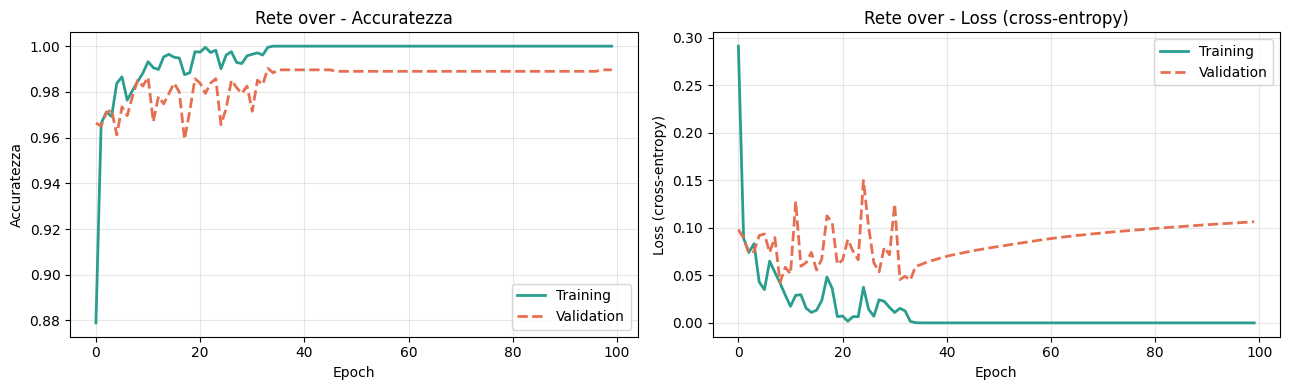

Rete over  - accuratezza test: 98.6%
Rete standard - accuratezza test: 98.4%


In [8]:
# Visualizziamo la divergenza training vs. validation: la firma dell'overfitting
fig, assi = plt.subplots(1, 2, figsize=(13, 4))

for asse, chiave, titolo in zip(
        assi,
        ['accuracy', 'loss'],
        ['Accuratezza', 'Loss (cross-entropy)']):
    asse.plot(storia_gig.history[chiave],
              label='Training', color='#2a9d8f', linewidth=2)
    asse.plot(storia_gig.history[f'val_{chiave}'],
              label='Validation', color='#e76f51', linewidth=2, linestyle='--')
    asse.set_xlabel('Epoch')
    asse.set_ylabel(titolo)
    asse.set_title(f'Rete over - {titolo}')
    asse.legend()
    asse.grid(True, alpha=0.3)

_, acc_gig = modello_over.evaluate(X_test_sc, y_test_0, verbose=0)

plt.tight_layout()
plt.show()

print(f"Rete over  - accuratezza test: {acc_gig:.1%}")
print(f"Rete standard - accuratezza test: {acc_mlp:.1%}")

## La soluzione: il Dropout

Il **Dropout** è una tecnica di regolarizzazione inventata nel 2014. È elegante nella sua semplicità: durante ogni passata di training, ogni neurone viene "spento" con probabilità $p$ (tipicamente 0.2-0.5). I neuroni spenti non contribuiscono all'uscita né ricevono aggiornamenti.

Questo forza la rete a non dipendere da nessun neurone in particolare, distribuendo l'informazione su tutto il network. Il risultato è un modello più robusto che generalizza meglio su dati nuovi.

**Nota**: il Dropout è attivo solo durante il training. In inferenza (previsione), tutti i neuroni sono attivi e i pesi vengono scalati automaticamente da Keras per compensare.

In [9]:
# Stessa architettura "gigante" ma con Dropout tra gli strati
modello_dropout = keras.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(X_train_sc.shape[1],)),
    keras.layers.Dropout(0.3),   # spegni il 30% dei neuroni ad ogni batch

    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(6, activation='softmax')
], name="rete_dropout")

modello_dropout.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

storia_drop = modello_dropout.fit(
    X_train_sc, y_train_0,
    epochs=100, batch_size=64, validation_split=0.2, verbose=1
)

_, acc_drop = modello_dropout.evaluate(X_test_sc, y_test_0, verbose=0)
print(f"Con Dropout - accuratezza test: {acc_drop:.1%}")

Epoch 1/100
97/97 [==============================] - 3s 9ms/step - loss: 0.5007 - accuracy: 0.7932 - val_loss: 0.1916 - val_accuracy: 0.9165
Epoch 2/100
97/97 [==============================] - 1s 7ms/step - loss: 0.1901 - accuracy: 0.9328 - val_loss: 0.1212 - val_accuracy: 0.9553
Epoch 3/100
97/97 [==============================] - 1s 7ms/step - loss: 0.1291 - accuracy: 0.9536 - val_loss: 0.0821 - val_accuracy: 0.9683
Epoch 4/100
97/97 [==============================] - 0s 5ms/step - loss: 0.1231 - accuracy: 0.9508 - val_loss: 0.1453 - val_accuracy: 0.9320
Epoch 5/100
97/97 [==============================] - 0s 5ms/step - loss: 0.1001 - accuracy: 0.9621 - val_loss: 0.0766 - val_accuracy: 0.9676
Epoch 6/100
97/97 [==============================] - 0s 5ms/step - loss: 0.0869 - accuracy: 0.9662 - val_loss: 0.0760 - val_accuracy: 0.9689
Epoch 7/100
97/97 [==============================] - 0s 5ms/step - loss: 0.0738 - accuracy: 0.9709 - val_loss: 0.0885 - val_accuracy: 0.9631
Epoch 8/100
9

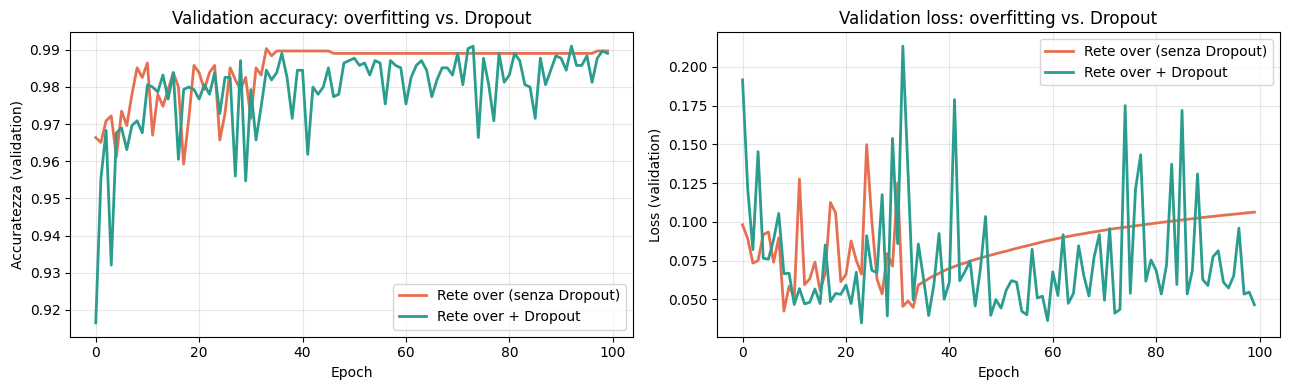

In [10]:
# Confronto visivo: gigante vs. gigante con Dropout
fig, assi = plt.subplots(1, 2, figsize=(13, 4))

# Accuratezza
assi[0].plot(storia_gig.history['val_accuracy'],
             label='Rete over (senza Dropout)', color='#e76f51', linewidth=2)
assi[0].plot(storia_drop.history['val_accuracy'],
             label='Rete over + Dropout', color='#2a9d8f', linewidth=2)
assi[0].set_xlabel('Epoch')
assi[0].set_ylabel('Accuratezza (validation)')
assi[0].set_title('Validation accuracy: overfitting vs. Dropout')
assi[0].legend()
assi[0].grid(True, alpha=0.3)

# Loss
assi[1].plot(storia_gig.history['val_loss'],
             label='Rete over (senza Dropout)', color='#e76f51', linewidth=2)
assi[1].plot(storia_drop.history['val_loss'],
             label='Rete over + Dropout', color='#2a9d8f', linewidth=2)
assi[1].set_xlabel('Epoch')
assi[1].set_ylabel('Loss (validation)')
assi[1].set_title('Validation loss: overfitting vs. Dropout')
assi[1].legend()
assi[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Tabella riassuntiva finale
df_finale = pd.DataFrame({
    "Modello": ["k-NN (k=5)", "Logistica", "MLP standard (128+64)",
                "MLP over (512x3 + 256)", "MLP over + Dropout(0.3)"],
    "Parametri": [
        "7724 campioni training",
        f"{LogisticRegression().fit(X_train_sc[:100], y_train_0[:100]).coef_.size} (6 x 561)",
        f"{mlp_comp.count_params():,}",
        f"{modello_over.count_params():,}",
        f"{modello_dropout.count_params():,}"
    ],
    "Accuratezza test": [
        f"{risultati_confronto[0]['Accuratezza']:.1%}",
        f"{risultati_confronto[1]['Accuratezza']:.1%}",
        f"{acc_mlp:.1%}",
        f"{acc_gig:.1%}",
        f"{acc_drop:.1%}"
    ]
})
print(df_finale.to_string(index=False))

                Modello              Parametri Accuratezza test
             k-NN (k=5) 7724 campioni training            96.3%
              Logistica         3366 (6 x 561)            98.1%
  MLP standard (128+64)                 80,582            98.4%
 MLP over (512x3 + 256)                945,926            98.6%
MLP over + Dropout(0.3)                945,926            98.4%


---

> **Cosa abbiamo imparato**: Le reti neurali non sono sempre le migliori. Per certi problemi, modelli più semplici come la regressione logistica o k-NN offrono prestazioni comparabili con molti meno parametri e complessità. La scelta del modello dipende dal contesto: disponibilità di dati, vincoli di memoria, tempo di inferenza richiesto. L'overfitting è il pericolo principale dei modelli complessi: una rete con troppi parametri memorizza il training set invece di generalizzare. Il Dropout è una tecnica efficace per prevenirlo: spegnendo casualmente neuroni durante il training, forza la rete a distribuire l'informazione.

> **Cosa faremo adesso?** Abbiamo il nostro modello finale: preciso, robusto, compatto. Ma come lo mettiamo nel chip del braccialetto? Nel prossimo notebook affronteremo il **deployment**: trasformeremo la rete Keras in un file ultra-compatto (TensorFlow Lite), la quantizzeremo per ridurre ulteriormente le dimensioni, e scriveremo il codice che gira su un microcontrollore. Benvenuti nell'Edge AI.